In [54]:
from sklearn.datasets import make_moons
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

import torch
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)

In [55]:
# Logistic Regression Implementation
class LogisticTorch:
    def __init__(self, lr=0.01, epochs=1000):
        self.lr = lr
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losses = []

    def fit(self, X, y):
        # Check if they're tensors or not
        if not isinstance(X, torch.Tensor):
            X = torch.from_numpy(X.astype(np.float32))
        if not isinstance(y, torch.Tensor):
            y = torch.from_numpy(y.astype(np.float32))
        n_samples, n_features = X.shape
        
        # Initialize weights and bias
        self.weights = torch.zeros(n_features, dtype=torch.float32, requires_grad=True)
        self.bias = torch.zeros(1, dtype=torch.float32, requires_grad=True)

        # Run SGD
        for _ in range(self.epochs):
            xtheta = X@self.weights + self.bias
            sigmoid_xtheta = torch.sigmoid(xtheta)
            sigmoid_xtheta = torch.clamp(sigmoid_xtheta, 1e-7, 1-1e-7) # to avoid log(0)
            # Binary cross-entropy loss
            loss = -torch.mean(y*torch.log(sigmoid_xtheta) + (1 - y)*torch.log(1 - sigmoid_xtheta))
            self.losses.append(loss.item())
            loss.backward() # calculate the gradient wrt loss
            with torch.no_grad():
                self.weights -= self.lr*self.weights.grad
                self.bias -= self.lr*self.bias.grad
            self.weights.grad.zero_()
            self.bias.grad.zero_()

    def predict_proba(self, X):
        if not isinstance(X, torch.Tensor):
            X = torch.from_numpy(X.astype(np.float32))
        return torch.sigmoid(X@self.weights + self.bias).detach().numpy()

    def predict(self, X):
        return (self.predict_proba(X) >= 0.5).astype(int)

In [56]:
# Getting the data

X, y = make_moons(n_samples=200, noise=0.2, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [57]:
# Training the data

# Using Logistic Regression from sklearn
sklearn_model = LogisticRegression(random_state=42, max_iter=1000)
sklearn_model.fit(X_train, y_train)

# Using Logistic Regression implemented with PyTorch
torch_model = LogisticTorch(0.1, 1000)
torch_model.fit(X_train, y_train)

In [58]:
# Test and compare the data
y_pred_torch = torch_model.predict(X_test)
y_pred_sk = sklearn_model.predict(X_test)

print("Accuracy from torch -> ", accuracy_score(y_pred_torch, y_test))
print("Accuracy from sk -> ", accuracy_score(y_pred_sk, y_test))

Accuracy from torch ->  0.85
Accuracy from sk ->  0.85


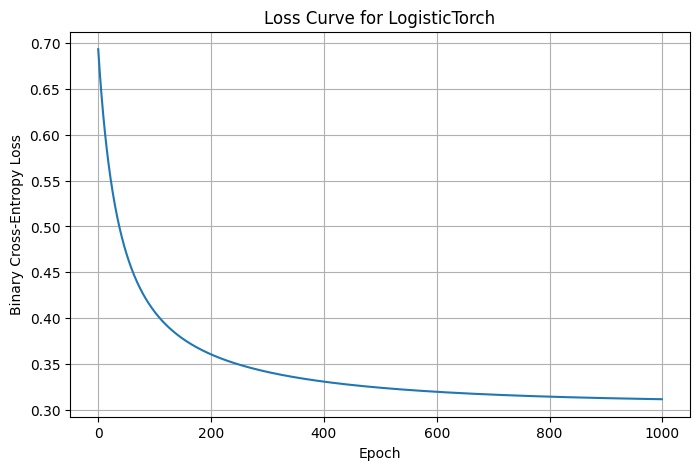

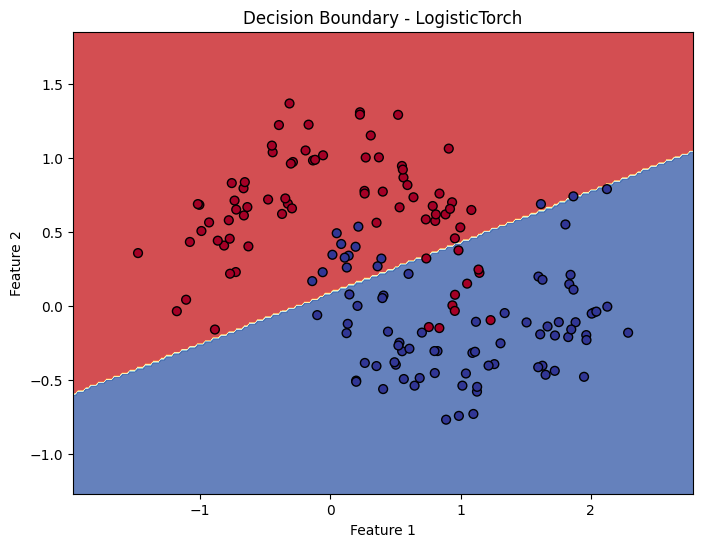

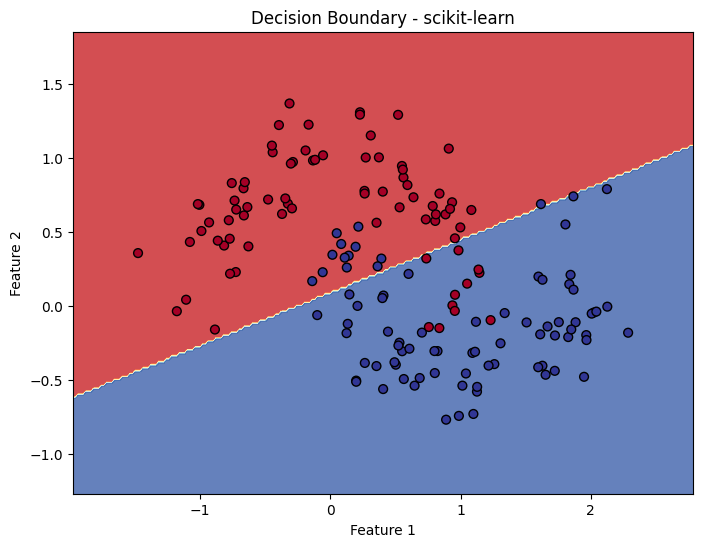

In [59]:
# --- Plotting ---

plt.figure(figsize=(8, 5))
plt.plot(range(torch_model.epochs), torch_model.losses)
plt.title('Loss Curve for LogisticTorch')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.grid(True)
plt.show()

def plot_decision_boundary(model, X, y, title):
    plt.figure(figsize=(8, 6))
    
    # Create a mesh grid
    x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
    y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                         np.arange(y_min, y_max, 0.02))
    
    # Get predictions for the grid
    grid_points = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid_points)
    Z = Z.reshape(xx.shape)
    
    # Plot the decision boundary and the data points
    plt.contourf(xx, yy, Z, cmap=plt.cm.RdYlBu, alpha=0.8)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.RdYlBu, edgecolors='k', s=40)
    plt.title(title)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.show()

# Plot decision boundaries for both models
plot_decision_boundary(torch_model, X_train, y_train, 'Decision Boundary - LogisticTorch')
plot_decision_boundary(sklearn_model, X_train, y_train, 'Decision Boundary - scikit-learn')